# Figure 2: Xenium colorectal cancer

Segger removes cross-cell transcript contamination without sacrificing marker sensitivity.
This notebook reproduces the panels of Fig. 2, starting from the public data.
Segger is compared with the Xenium onboard cell segmentation (10x Cell) and its nuclei (10x Nucleus), Proseg, Baysor and Bering on a Xenium colorectal cancer (CRC) section acquired with the Cell Segmentation Staining workflow (Oliveira et al., 2025).
Cell types are assigned by cosine similarity to a matched 10x Chromium Flex reference from serial sections of the same FFPE blocks.

| | |
|---|---|
| Data | Xenium CRC section (422 genes), segmentations of all methods, matched scRNA-seq reference; 4.2 GB download |
| Compute | CPU, 16 GB RAM, about 10 min. `segger segment` needs a CUDA GPU (about 25 min on one A100). |
| Output | `results/figure_2/panel_{a,b,c,d}.{pdf,png}` |

In [1]:
import subprocess
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc

import sg_utils as sg
from sg_utils.pl import fov
from sg_utils.pl.style import MM
from sg_utils.tl import boundaries, celltyping, metrics

sg.pl.set_style()
warnings.filterwarnings("ignore", message="Variable names are not unique")  # the reference has 3 duplicated gene names

In [2]:
DATA_DIR = Path("../data")
OUT_DIR = Path("../results/figure_2")
RUN_SEGGER = False  # True runs `segger segment` (CUDA GPU); False downloads the published segmentation
PAPER_BENCHMARK = True  # panel d draws the benchmark values of the paper for coverage and spurious co-expression; False draws the values computed here
N_JOBS = 8  # processes for cell outlines

## Download the data

The Xenium output bundle comes from 10x Genomics (Human Colon Preview Data, section `Human_Colon_Cancer_P1_CRC_Add_on`).
Only the files used below are extracted from the 13 GB archive.
The per-transcript assignments of Proseg, Baysor and Bering, the scRNA-seq reference and the benchmark scores are hosted with the paper.

In [3]:
files = ["xenium", "segmentations", "reference"] + ([] if RUN_SEGGER else ["segger"]) + (["benchmark"] if PAPER_BENCHMARK else [])
paths = sg.datasets.fetch("xenium_crc", DATA_DIR, files=files)
paths

{'xenium': PosixPath('../data/xenium_crc/xenium'),
 'segger': PosixPath('../data/xenium_crc/segger/segger_segmentation.parquet'),
 'segmentations': PosixPath('../data/xenium_crc/segmentations.parquet'),
 'reference': PosixPath('../data/xenium_crc/human_crc_flex_reference.h5ad'),
 'benchmark': PosixPath('../data/xenium_crc/benchmark_scores.tsv')}

## Run Segger

`segger segment` reads the Xenium directory, removes transcripts with a quality value below 20 and control probes, builds the graph of transcripts and cells, trains the model and writes `segger_segmentation.parquet` (one row per transcript) and `segger_anndata.h5ad` (cells x genes) to the output directory.
The candidate cells of a transcript are the cells whose initial mask, grown by a fraction of the cell radius (the receptive field), contains it; for Fig. 2 masks are grown by 10% of the radius (`--prediction-graph-buffer-ratio 0.1`, default 0.05).
The section is processed in tiles that overlap by 8 µm (`--tiling-margin-training`, `--tiling-margin-prediction`, default 20 µm).
`segger segment --help` lists all options.

In [4]:
segger_dir = DATA_DIR / "xenium_crc" / "segger"
segger_dir.mkdir(parents=True, exist_ok=True)
if RUN_SEGGER:
    subprocess.run([
        "segger", "segment", "-i", paths["xenium"], "-o", segger_dir,
        "--prediction-graph-buffer-ratio", "0.1", "--tiling-margin-training", "8", "--tiling-margin-prediction", "8",
    ], check=True)

## Segger's output

`segger_segmentation.parquet` has one row per transcript that passed the quality and control filters: `row_index` (its row in `transcripts.parquet`), `x`, `y`, `feature_name`, `segger_cell_id` (the candidate cell with the highest similarity; empty without a candidate), `segger_similarity`, `similarity_threshold`, `converged` and `filtered`.
The threshold of a gene is the smaller of the Yen and Li thresholds of its similarities; when the Li search does not converge, the gene takes the median threshold of the other genes and `converged` is false.
`filtered` marks the kept assignments: a candidate cell, a converged gene threshold and a similarity at or above it.
The file published with the paper predates `x`, `y`, `feature_name` and `filtered`; `sg.io.read_segger` adds `filtered` with the same rule.
`segger export anndata boundaries -s segger_segmentation.parquet -o <directory>` writes the kept assignments as `adata.h5ad` (cells with at least 10 transcripts, `--min-counts`) and `cell_boundaries.parquet` (Delaunay outlines, smoothed with `--chaikin-iterations`).

In [5]:
segger = sg.io.read_segger(segger_dir / "segger_segmentation.parquet")
print(f"{segger.height:,} transcripts scored; {segger['segger_cell_id'].is_not_null().mean():.1%} have a candidate cell and {segger['filtered'].mean():.1%} are kept")
segger.head()

27,335,510 transcripts scored; 82.8% have a candidate cell and 66.6% are kept


row_index,segger_similarity,segger_cell_id,similarity_threshold,converged,filtered
i64,f32,cat,f64,bool,bool
0,0.28325,"""dilhemok-1""",0.382048,true,false
1,0.0,null,0.37522,true,false
2,0.0,null,0.38618,true,false
4,0.790292,"""dilhemok-1""",0.38618,true,true
5,0.0,null,0.38618,true,false


## Load transcripts and segmentations

One row per transcript and one cell-id column per method.
The `Segger` column holds the kept assignments (`filtered`).
Only transcripts scored by Segger are kept, so all methods are evaluated on the same molecules.

In [6]:
transcripts_path = paths["xenium"] / "transcripts.parquet"
tx = sg.io.join_assignments(
    sg.io.read_transcripts(transcripts_path, columns=["cell_id", "overlaps_nucleus"], lazy=True),
    segger.lazy(),
    sg.io.read_segmentations(paths["segmentations"], lazy=True),
)
del segger
METHODS = sg.pl.METHODS
tx.select("row_index", "x", "y", "feature_name", *METHODS).head()

row_index,x,y,feature_name,Segger,10x Cell,10x Nucleus,Proseg,Baysor,Bering
i64,f32,f32,cat,cat,cat,cat,cat,cat,cat
0,16.344997,30.472748,"""COMP""",null,null,null,"""0""","""CRad21a3dc4-1""","""48897"""
1,18.07774,76.656639,"""RSPO3""",null,null,null,null,"""CRad21a3dc4-29""",null
2,22.796055,153.831589,"""HLA-DRA""",null,null,null,null,"""CRad21a3dc4-145""","""48823"""
4,26.476801,30.570494,"""HLA-DRA""","""dilhemok-1""","""dilhemok-1""","""dilhemok-1""","""0""","""CRad21a3dc4-2""","""48536"""
5,26.691698,153.958511,"""HLA-DRA""",null,null,null,null,"""CRad21a3dc4-145""",null


## Reference profiles and marker genes

Markers are discovered once on the reference, restricted to the panel, before any segmentation is scored.
Positive markers of a type: adjusted P < 0.01, log2 fold change > 1, detected in at least half of its cells (12 highest-scoring).
Contamination markers: adjusted P < 0.01, log2 fold change < −1, detected in under a tenth of its cells (12 most depleted).

In [7]:
reference = ad.read_h5ad(paths["reference"])
reference.var_names_make_unique()
panel = sorted(tx.get_column("feature_name").unique())

profiles = celltyping.reference_profiles(reference, "Level1", genes=panel)
ranked = celltyping.rank_reference_genes(reference, "Level1", genes=panel)
positive = celltyping.positive_markers(ranked)
contamination = celltyping.contamination_markers(ranked)

pd.DataFrame(
    {"positive markers": {t: ", ".join(g) for t, g in positive.items()},
     "contamination markers": {t: ", ".join(g) for t, g in contamination.items()}}
)

,positive markers,contamination markers
B cells,"CD79A, MZB1, DERL3, SEC11C, FKBP11","IL32, CEACAM6, THBS1, GPX2, IFI27, IGFBP7, SEL..."
Endothelial,"PECAM1, VWF, CDH5, IGFBP7, PLVAP, AQP1, TIMP3,...","LCN2, MYH14, SLC7A5, PPP1R1B, S100P, TRAC, CD7..."
Fibroblast,"MMP2, C3, IGFBP7, VCAN, TIMP3, THBS1, TAGLN, CTSB","CEACAM6, GPX2, SEC11C, LCN2, MYH14, SLC7A5, S1..."
Intestinal Epithelial,"PIGR, MUC12, FABP1, MUC5B, SELENBP1, LCN2, CD2...","IGFBP7, TIMP3, TGFBI, SLC7A5, PECAM1, MMP2, SO..."
Myeloid,"CTSB, C1QC, C1QB, C1QA, CD68, CYBB, CD163, CD1...","SLC12A2, SELENBP1, GPX2, PRSS23, MYC, ETS1, IF..."
Neuronal,"CLU, CRYAB, TIMP3, IGFBP7","IL32, CEACAM6, CXCR4, GPX2, MYC, SLC12A2, LCN2..."
Smooth Muscle,"TAGLN, DES, ACTA2","CEACAM6, IL32, GPX2, PPDPF, CXCR4, IFI27, ATP5..."
T cells,"TRAC, TRBC2, ETS1, IL7R, CXCR4, CD2, IL32","CEACAM5, CD24, CEACAM6, THBS1, GPX2, IFI27, IG..."
Tumor,"CEACAM5, CEACAM6, CD24, GPX2, SLC12A2, PPDPF, ...","DES, ACTA2, SELENOM, PECAM1, SOCS3, CD79A, MAF..."


Specificity and spurious co-expression use gene pairs that are semi-exclusive in 10x nuclei: both genes are detected in at least 1% of nuclei and the Jaccard index of the nuclei detecting them is below 0.10 (the 500 most exclusive pairs).
Each gene belongs to the reference type with its highest mean expression.
In a pair from two types, each gene is a clean marker of its own type when its partner is detected in fewer than 1% of that type's reference cells; a type keeps one clean marker per partner, from the most exclusive pair.

In [8]:
pairs = metrics.exclusive_gene_pairs(sg.io.read_transcripts(transcripts_path, columns=["cell_id", "overlaps_nucleus"]))
detection = celltyping.detection_rates(reference, "Level1", genes=panel)
host_genes = metrics.pair_host_genes(pairs, profiles, detection)
pairs.head()

,gene_a,gene_b,nuclear_jaccard,nuclei_a,nuclei_b,cyto_ratio_a,cyto_ratio_b
0,SELL,WFDC2,0.001849,3446.0,4140.0,0.562967,1.253367
1,MT1A,SELL,0.002204,4738.0,3446.0,1.307167,0.562967
2,CD27,MUC12,0.002220,3827.0,8362.0,0.716766,1.806785
3,LTB,WFDC2,0.002412,6667.0,4140.0,0.733549,1.253367
4,MS4A1,MT1A,0.002459,17688.0,4738.0,0.339056,1.307167


## Metrics per method

Cells with fewer than 20 assigned transcripts are discarded.
Cell counts, transcripts per cell, specificity and spurious co-expression use all panel genes.
Cell typing, positive marker recall (PMR) and cell-typing confidence use the genes shared with the reference.
For PMR, a marker is available to a cell when a transcript of it with QV ≥ 20, assigned or not, lies within 10 µm of the cell centroid (the mean position of all its transcripts); PMR and cell-typing confidence are summarised over the cells with at least one available marker.

In [9]:
field = sg.io.read_transcripts(transcripts_path, lazy=True)  # all transcripts with QV ≥ 20
rows, per_cell, tables = [], {}, {}
for method in METHODS:
    adata = metrics.cell_by_gene(tx, method, genes=panel, min_transcripts=20)
    tables[method] = adata
    celltyping.assign_cell_types(adata, profiles)
    adata_ref = metrics.cell_by_gene(tx, method, genes=list(profiles.columns), min_transcripts=20)
    adata_ref.obsm["spatial"] = adata[adata_ref.obs_names].obsm["spatial"]
    celltyping.assign_cell_types(adata_ref, profiles)

    pmr = metrics.positive_marker_recall(adata_ref, positive, profiles, field)
    scored = pmr.notna().to_numpy()
    spec = metrics.specificity(adata, host_genes, contamination)
    sce = metrics.spurious_coexpression(adata, pairs)
    n_tx = adata.obs["n_transcripts"]
    confidence = adata_ref.obs["cell_type_confidence"][scored]
    rows.append({
        "method": method,
        "cells": adata.n_obs,
        "tx_per_cell": n_tx.median(), "tx_per_cell_q1": n_tx.quantile(0.25), "tx_per_cell_q3": n_tx.quantile(0.75),
        "coverage": 100 * metrics.coverage(tx, method),
        "pmr": np.average(pmr[scored], weights=adata_ref.obs["n_transcripts"][scored]),
        "specificity": spec["specificity"], "sce": sce["sce"],
        "confidence": confidence.median(), "confidence_q1": confidence.quantile(0.25), "confidence_q3": confidence.quantile(0.75),
    })
    per_cell[method] = adata.obs[["n_transcripts", "cell_type"]].assign(
        x=adata.obsm["spatial"][:, 0], y=adata.obsm["spatial"][:, 1]
    )

summary = pd.DataFrame(rows).set_index("method")
summary.loc["10x Nucleus", "sce"] = np.nan  # 10x Nucleus is the reference of spurious co-expression
summary.style.format({"coverage": "{:.1f}", "pmr": "{:.2f}", "specificity": "{:.4f}", "sce": "{:.2e}", "confidence": "{:.3f}", "confidence_q1": "{:.3f}", "confidence_q3": "{:.3f}"})

,cells,tx_per_cell,tx_per_cell_q1,tx_per_cell_q3,coverage,pmr,specificity,sce,confidence,confidence_q1,confidence_q3
method,,,,,,,,,,,
Segger,208423,58.000000,34.000000,107.000000,66.6,85.52,0.6398,3.26e-05,0.591,0.506,0.663
10x Cell,247075,65.000000,39.000000,113.000000,81.4,85.05,0.4146,2.61e-04,0.523,0.418,0.606
10x Nucleus,178762,43.000000,29.000000,70.000000,40.4,74.68,0.4237,nan,0.536,0.433,0.623
Proseg,235135,72.000000,42.000000,130.000000,89.5,84.79,0.5864,1.83e-04,0.573,0.476,0.654
Baysor,374834,53.000000,33.000000,88.000000,98.7,78.04,0.4826,3.68e-05,0.539,0.434,0.626
Bering,202266,50.000000,33.000000,77.000000,46.8,76.57,0.5537,5.30e-05,0.551,0.448,0.625


## Panel a: cross-cell contamination

A 60 × 60 µm epithelial and tumour field.
Black outlines are epithelial and tumour cells, blue points their transcripts, orange points stromal transcripts assigned to them.
The stromal genes are nearly absent from epithelial and tumour cells in the reference:

In [10]:
STROMAL = ["FAP", "COL11A1", "MMP1", "RARRES2", "ROBO2"]
HOST_TYPES = ["Tumor", "Intestinal Epithelial"]
(100 * detection.loc[HOST_TYPES, STROMAL]).round(2)

,FAP,COL11A1,MMP1,RARRES2,ROBO2
Tumor,1.30,1.44,2.60,1.68,0.32
Intestinal Epithelial,0.26,0.21,0.53,5.66,0.48


Outlines of Segger, Proseg, Baysor and Bering are Delaunay outlines of each cell's transcripts, smoothed by two rounds of Chaikin corner cutting (`segger export boundaries --chaikin-iterations 2`); 10x outlines are the native image masks.

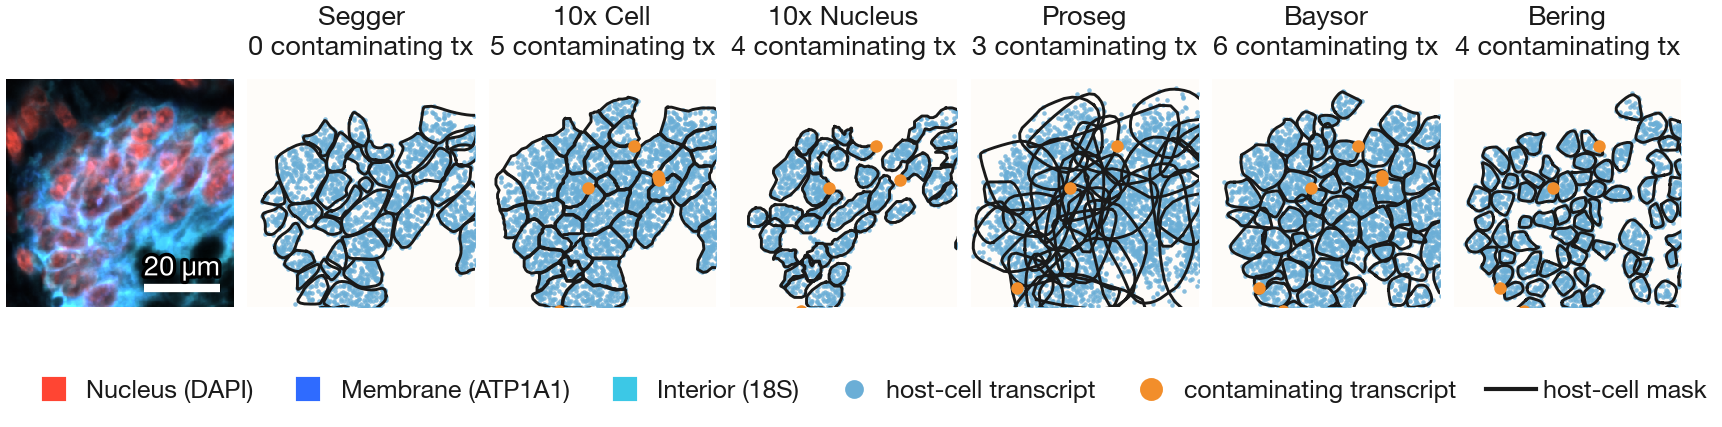

In [11]:
def masks_for(method, cells):
    """Outlines of `cells` in `method`."""
    if method in ("10x Cell", "10x Nucleus"):
        table = "cell_boundaries.parquet" if method == "10x Cell" else "nucleus_boundaries.parquet"
        return sg.io.read_xenium_boundaries(paths["xenium"] / table, cells=cells)
    cell_tx = tx.filter(pl.col(method).is_in(list(cells)))
    return boundaries.cell_boundaries(cell_tx, method, smoothing=2)


def cells_in(method, bbox, types=None, margin=4.0):
    """QC-passing cells of `method` with their centroid in `bbox`, optionally of given types."""
    x0, y0, x1, y1 = bbox
    cells = per_cell[method]
    keep = cells["x"].between(x0 - margin, x1 + margin) & cells["y"].between(y0 - margin, y1 + margin)
    if types is not None:
        keep &= cells["cell_type"].isin(types)
    return list(cells.index[keep])


def morphology(bbox, gain=1.0):
    image = sg.io.read_morphology(paths["xenium"] / "morphology_focus" / "morphology_focus_0000.ome.tif", bbox, channels=[0, 1, 2])
    return fov.morphology_rgb(image, [fov.DAPI_RED, fov.MEMBRANE_BLUE, fov.INTERIOR_CYAN], gain=gain)


center, half = (3488.6, 4307.2), 30.0
bbox_a = (center[0] - half, center[1] - half, center[0] + half, center[1] + half)
fov_a = tx.filter(pl.col("x").is_between(bbox_a[0] - 20, bbox_a[2] + 20) & pl.col("y").is_between(bbox_a[1] - 20, bbox_a[3] + 20))

CHANNELS = {"Nucleus (DAPI)": fov.DAPI_RED, "Membrane (ATP1A1)": fov.MEMBRANE_BLUE, "Interior (18S)": fov.INTERIOR_CYAN}
fig, axes = plt.subplots(2, 7, figsize=(183 * MM, 40 * MM), gridspec_kw={"wspace": 0.06, "height_ratios": [1, 0.22]})
fov.image(axes[0, 0], morphology(bbox_a, gain=0.9), bbox_a)
fov.scale_bar(axes[0, 0], 20)
for ax, method in zip(axes[0, 1:], METHODS):
    host = cells_in(method, bbox_a, HOST_TYPES)
    n = fov.contamination(ax, fov_a, method, masks_for(method, host), STROMAL, bbox_a)
    ax.set_title(f"{method}\n{n} contaminating tx", fontsize=6.5, linespacing=1.3)
legend = fig.add_subplot(axes[1, 0].get_gridspec()[1, :])
for ax in axes[1]:
    ax.remove()
fov.contamination_legend(legend, CHANNELS)
sg.pl.save_panel(fig, OUT_DIR / "panel_a")

## Panel b: positive marker recall

A tumour epithelial cell in a 30 × 30 µm field, with four tumour markers.
For each method the focal cell is the cell holding most of the transcripts of the 10x cell `igplniip-1`.

Tumor positive markers: CEACAM5, CEACAM6, CD24, GPX2, SLC12A2, PPDPF, MUC12, LAMP1


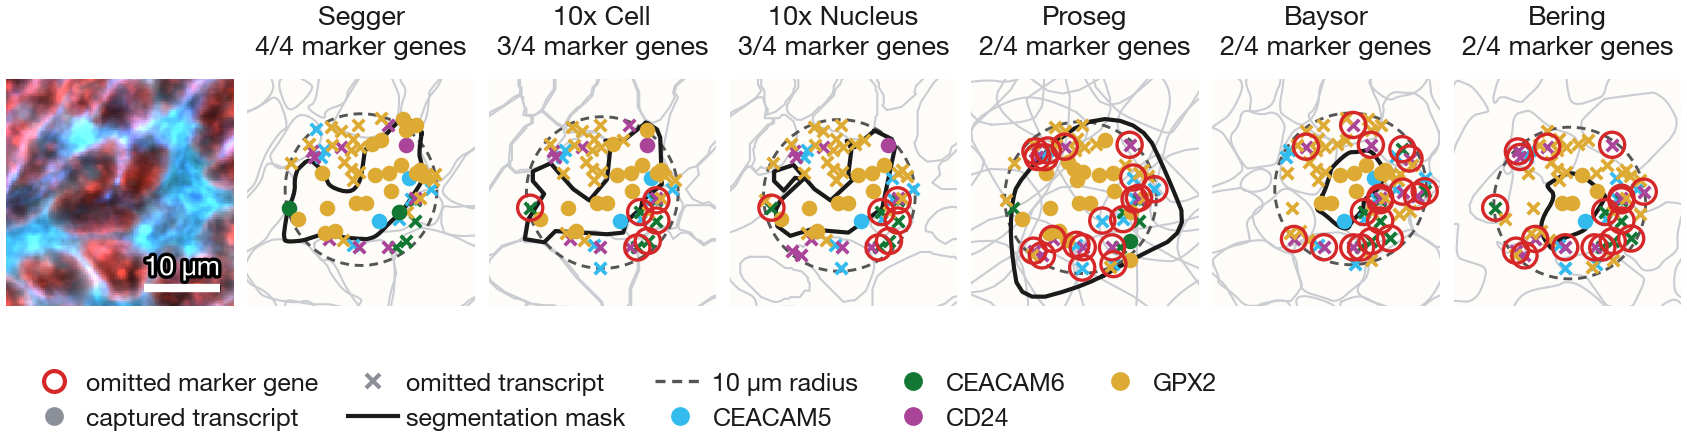

In [12]:
MARKERS = {"CEACAM5": "#33BBEE", "CEACAM6": "#117733", "CD24": "#AA4499", "GPX2": "#DDAA33"}
print("Tumor positive markers:", ", ".join(positive["Tumor"]))

reference_cell = tx.filter(pl.col("10x Cell") == "igplniip-1")
center = tuple(reference_cell.select(pl.col("x").mean(), pl.col("y").mean()).row(0))
half = 15.0
bbox_b = (center[0] - half, center[1] - half, center[0] + half, center[1] + half)
fov_b = tx.filter(pl.col("x").is_between(bbox_b[0] - 15, bbox_b[2] + 15) & pl.col("y").is_between(bbox_b[1] - 15, bbox_b[3] + 15))

fig, axes = plt.subplots(2, 7, figsize=(183 * MM, 42 * MM), gridspec_kw={"wspace": 0.06, "height_ratios": [1, 0.3]})
fov.image(axes[0, 0], morphology(bbox_b), bbox_b)
fov.scale_bar(axes[0, 0], 10)
for ax, method in zip(axes[0, 1:], METHODS):
    focal = reference_cell.get_column(method).drop_nulls().mode().sort()[0]
    focal_center = tuple(tx.filter(pl.col(method) == focal).select(pl.col("x").mean(), pl.col("y").mean()).row(0))
    masks = masks_for(method, cells_in(method, bbox_b, margin=10) + [focal])
    recovered, available = fov.marker_recall(ax, fov_b, method, focal, focal_center, MARKERS, masks, bbox_b)
    ax.set_title(f"{method}\n{recovered}/{available} marker genes", fontsize=6.5, linespacing=1.3)
legend = fig.add_subplot(axes[1, 0].get_gridspec()[1, :])
for ax in axes[1]:
    ax.remove()
fov.marker_recall_legend(legend, MARKERS)
sg.pl.save_panel(fig, OUT_DIR / "panel_b")

## Panel c: sensitivity–specificity trade-off

PMR of a cell is the expression-weighted share of its type's positive markers present within 10 µm of its centroid that the cell holds; the section value averages cells weighted by their transcript counts.
Specificity is clean/(clean + FP): clean transcripts are clean markers of the host type (from the nuclear semi-exclusive pairs above) assigned to cells of that type, FP transcripts contamination markers of the assigned host type.

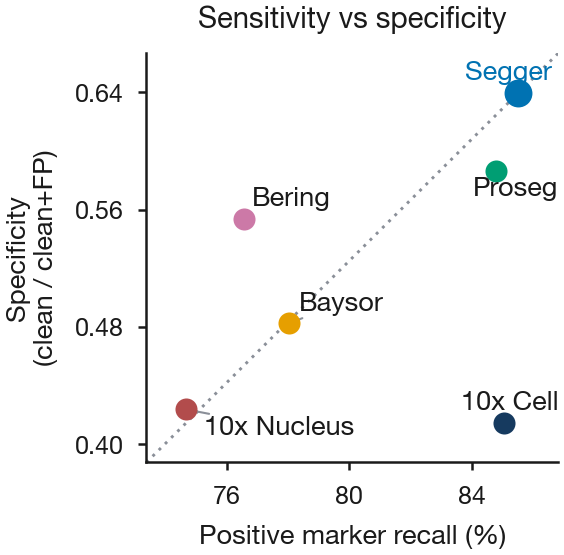

In [13]:
fig, ax = plt.subplots(figsize=(45 * MM, 45 * MM))
sg.pl.benchmark.tradeoff(
    ax, summary, "pmr", "specificity",
    xlabel="Positive marker recall (%)", ylabel="Specificity\n(clean / clean+FP)",
)
ax.set_title("Sensitivity vs specificity")
sg.pl.save_panel(fig, OUT_DIR / "panel_c")

## Panel d: per-method summary statistics

Cells after filtering, median transcripts per cell, percentage of transcripts assigned to a cell, spurious co-expression and cell-typing confidence; dashed lines mark the Segger value.
In the paper, the percentage of transcripts assigned and spurious co-expression are the benchmark scores of Supplementary Fig. 3.2, computed by `segger validate` (on the `integration/all` branch of segger) for the benchmark runs of each method, with Segger in its default configuration.
With `PAPER_BENCHMARK = False` the panel shows the values computed above for this Segger run.
Error bars are the 25th–75th percentiles over cells.
Spurious co-expression is not reported for 10x Nucleus, which is its reference.

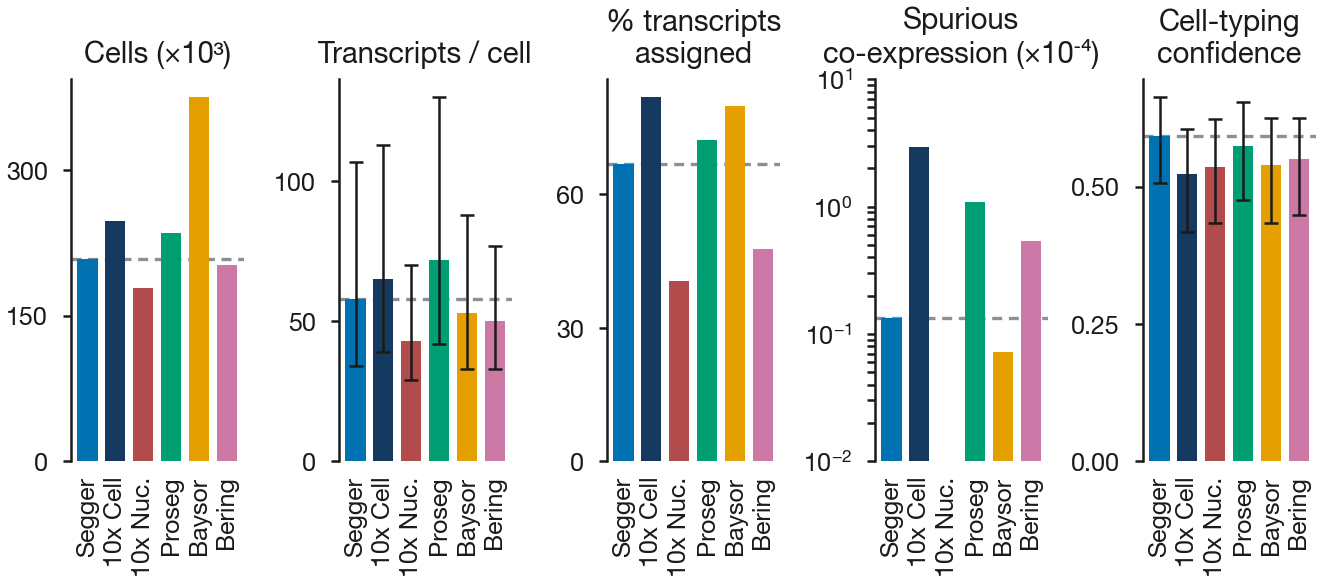

In [14]:
stats = summary.copy()
if PAPER_BENCHMARK:
    RUNS = {"default": "Segger", "ref_10x_cell": "10x Cell", "ref_10x_nucleus": "10x Nucleus", "proseg": "Proseg", "baysor": "Baysor", "bering": "Bering"}
    benchmark = pd.read_csv(paths["benchmark"], sep="\t").query("dataset == 'xenium_crc' and method in @RUNS")
    benchmark = benchmark.assign(method=benchmark["method"].map(RUNS)).pivot(index="method", columns="metric", values="value")
    stats["coverage"] = benchmark["pct_assigned"]
    stats["sce"] = benchmark["spurious_coexpression"]

short = {"10x Nucleus": "10x Nuc."}
fig, axes = plt.subplots(1, 5, figsize=(136 * MM, 42 * MM), gridspec_kw={"wspace": 0.55})
sg.pl.benchmark.bars(axes[0], stats["cells"] / 1e3, title="Cells (×10³)", labels=short)
sg.pl.benchmark.bars(axes[1], stats["tx_per_cell"], stats["tx_per_cell_q1"], stats["tx_per_cell_q3"], title="Transcripts / cell", labels=short)
sg.pl.benchmark.bars(axes[2], stats["coverage"], title="% transcripts\nassigned", labels=short)
sg.pl.benchmark.bars(axes[3], stats["sce"] * 1e4, title="Spurious\nco-expression (×10⁻⁴)", log=True, labels=short)
sg.pl.benchmark.bars(axes[4], stats["confidence"], stats["confidence_q1"], stats["confidence_q3"], title="Cell-typing\nconfidence", labels=short)
sg.pl.save_panel(fig, OUT_DIR / "panel_d")

## Comparison with the paper

Values of Fig. 2 next to the values computed above; the percentage of transcripts assigned and spurious co-expression in panel d are the benchmark scores and are not recomputed here.
Segger's values are those of the paper.
The paper scored the other methods on an internal table of all segmentations whose transcripts could not be reconstructed from the public files; their values here differ by up to 5% and rank the methods in the same order.

In [15]:
PAPER = {
    "cells": {"Segger": 208_423, "10x Cell": 253_447, "10x Nucleus": 179_874, "Proseg": 240_835, "Baysor": 382_769, "Bering": 210_837},
    "transcripts per cell": {"Segger": 58, "10x Cell": 63, "10x Nucleus": 43, "Proseg": 70, "Baysor": 51, "Bering": 48},
    "PMR (%)": {"Segger": 85.521177, "10x Cell": 84.893393, "10x Nucleus": 74.494822, "Proseg": 84.667022, "Baysor": 77.928816, "Bering": 76.280236},
    "specificity": {"Segger": 0.639775, "10x Cell": 0.419708, "10x Nucleus": 0.426722, "Proseg": 0.595606, "Baysor": 0.489435, "Bering": 0.558794},
    "cell-typing confidence": {"Segger": 0.591472, "10x Cell": 0.521572, "10x Nucleus": 0.535213, "Proseg": 0.573257, "Baysor": 0.539292, "Bering": 0.552396},
}
computed = {
    "cells": summary["cells"], "transcripts per cell": summary["tx_per_cell"], "PMR (%)": summary["pmr"],
    "specificity": summary["specificity"], "cell-typing confidence": summary["confidence"],
}
comparison = pd.DataFrame(
    [{"metric": k, "method": m, "paper": v, "this notebook": float(computed[k][m])} for k, d in PAPER.items() for m, v in d.items()]
).set_index(["metric", "method"])
comparison["difference"] = comparison["this notebook"] - comparison["paper"]
comparison.style.format({"paper": "{:.6g}", "this notebook": "{:.6g}", "difference": "{:.2g}"})

## Save as SpatialData

The transcripts with the assignment of every method, the cell x gene table of each method and the cell outlines are written to one SpatialData Zarr store, which `spatialdata.read_zarr`, SOPA and napari-spatialdata read.
Element names follow `segger export spatialdata`: points `transcripts`, shapes `cell_boundaries_<method>` and tables `table_<method>`.
Segger outlines are computed as in `segger export boundaries`; the 10x outlines are the native masks.
The store takes about 1 GB.

In [16]:
outlines = {
    "Segger": boundaries.cell_boundaries(tx, "Segger", cells=list(tables["Segger"].obs_names), smoothing=0, n_jobs=N_JOBS),
    "10x Cell": sg.io.read_xenium_boundaries(paths["xenium"] / "cell_boundaries.parquet", cells=list(tables["10x Cell"].obs_names)),
    "10x Nucleus": sg.io.read_xenium_boundaries(paths["xenium"] / "nucleus_boundaries.parquet", cells=list(tables["10x Nucleus"].obs_names)),
}
sdata = sg.io.write_spatialdata(OUT_DIR / "xenium_crc.zarr", tx.select("x", "y", "feature_name", *METHODS), tables, outlines, overwrite=True)
sdata

SpatialData object, with associated Zarr store: /Users/b450-admin/Desktop/Projects/Active/segger/release/segger-analysis/results/figure_2/xenium_crc.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 9) (2D points)
├── Shapes
│     ├── 'cell_boundaries_10x_cell': GeoDataFrame shape: (247075, 1) (2D shapes)
│     ├── 'cell_boundaries_10x_nucleus': GeoDataFrame shape: (178762, 1) (2D shapes)
│     └── 'cell_boundaries_segger': GeoDataFrame shape: (208423, 1) (2D shapes)
└── Tables
      ├── 'table_10x_cell': AnnData (247075, 421)
      ├── 'table_10x_nucleus': AnnData (178762, 421)
      ├── 'table_baysor': AnnData (374834, 421)
      ├── 'table_bering': AnnData (202266, 421)
      ├── 'table_proseg': AnnData (235135, 421)
      └── 'table_segger': AnnData (208423, 421)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries_10x_cell (Shapes), cell_boundaries_10x_nucleus (Shapes), cell_boundaries_segger (Shapes)

## Software versions

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # deprecation notices raised while reading package versions
    display(sc.logging.print_header())

Package,Version
spatialdata,0.4.0
pandas,2.2.3
anndata,0.11.4
matplotlib,3.10.1
numpy,2.2.5
polars,1.44.2
scanpy,1.11.4
geopandas,1.0.1
Component,Info
Python,"3.11.15 (main, May 8 2026, 18:24:56) [Clang 22.1.3 ]"
